# Introduction

**Research Question**:  
How does rider demand fluctuate across different times of the day, days of the week, and seasons?

This research question explores temporal patterns in B-Line rider demand. By analyzing how boardings vary throughout the day, across weekdays, and by season, we aim to uncover trends that can guide more efficient transit scheduling and operations.


## Variables

**Dependent Variable (Outcome):**
- `boardings` – number of passengers boarding per observation  *(from `RidershipData.csv`)*

**Independent Variables (Predictors):**
- `hour` – time of day, *(in `RidershipData.csv`)*
- `day_of_week` – day name *(`RidershipData.csv`)*
- `season` – categorical variable based on month  *(in `RidershipData.csv`)*
- `date` – *(in `RidershipData.csv`)*

All variables are sourced from `RidershipData.csv`, which provides timestamped entries for boardings across the B-Line system.


## Statistical Plan

**Preprocessing:**  
- Convert `timestamp` to datetime  
- Aggregate boardings (hourly, daily)  
- Handle missing values  
- Create lag or rolling features (if needed)  

To analyze temporal rider demand fluctuations, the following methods will be used:

- **Data Aggregation**: Summarize boardings by hour, day of the week, and season.
- **Visualization**: Use line plots, bar charts, and heatmaps to display demand variation.
- **(Optional) Forecasting Models**: Depending on the goal, models like ARIMA or ETS may be used for demand prediction.

These methods will help surface actionable insights into when transit demand is highest or lowest, supporting service optimization.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Step 1: Load & Inspect the Validation Data.

In [3]:


# Step 1.1: Load the dataset
file_path = "C:/Users/zelaskar/Box/2024 Zakir Elaskar/data/Combined datasets/validation_combined_union.csv"  
df = pd.read_csv(file_path)

# Step 1.2: Quick look at the data
print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns.tolist())

# Step 1.3: Peek at first few rows
df.head()

# Step 1.4: Info about data types and missing values
df.info()

# Step 1.5: Check if there’s a timestamp column
if 'timestamp' in df.columns:
    print("\nSample timestamps:\n", df['timestamp'].head())


C:\Users\zelaskar\AppData\Local\Temp\ipykernel_12812\2747611202.py:3: DtypeWarning: Columns (10,17,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Shape of dataset: (134548, 26)

Column names:
 ['timestamp', 'validation_id', 'user_id', 'pass_id', 'pass_agency_id', 'fare_id', 'fare_type', 'rider_type', 'validator_id', 'vehicle_number', 'stop_id', 'stop_code', 'stop_name', 'stop_lat', 'stop_lon', 'trip_id', 'gtfs_route_id', 'route_id', 'route_long_name', 'all_rts', 'riders_by_rt', 'origin', 'validator_lat', 'validator_lon', 'id', 'source_file']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134548 entries, 0 to 134547
Data columns (total 26 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   timestamp        134548 non-null  object 
 1   validation_id    134299 non-null  object 
 2   user_id          134210 non-null  object 
 3   pass_id          134194 non-null  object 
 4   pass_agency_id   134548 non-null  object 
 5   fare_id          134548 non-null  object 
 6   fare_type        134548 non-null  object 
 7   rider_type       134548 non-null  object 
 8   validator_id

In [4]:
# Convert timestamp column to datetime (while checking errors)
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', infer_datetime_format=True)

# Drop rows where timestamp couldn't be parsed (if any)
df = df.dropna(subset=['timestamp'])

# Check the range of dates
min_date = df['timestamp'].min()
max_date = df['timestamp'].max()

print("Date range in validation dataset:")
print("Start:", min_date)
print("End:", max_date)

# Optional: count how many unique days are covered
unique_days = df['timestamp'].dt.date.nunique()
print("\nTotal unique days covered:", unique_days)


Date range in validation dataset:
Start: 2023-01-02 06:33:00
End: 2025-03-31 21:08:00

Total unique days covered: 745


C:\Users\zelaskar\AppData\Local\Temp\ipykernel_12812\1961627609.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', infer_datetime_format=True)


Step 2 Pre-processing

In [5]:
# Extract time-based features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()
df['month'] = df['timestamp'].dt.month

# Map months to seasons
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
}
df['season'] = df['month'].map(season_map)

# Quick check
print(df[['timestamp', 'hour', 'day_of_week', 'month', 'season']].head())


            timestamp  hour day_of_week  month  season
0 2023-01-04 09:00:00     9   Wednesday      1  Winter
1 2023-01-17 11:29:00    11     Tuesday      1  Winter
2 2023-01-21 11:11:00    11    Saturday      1  Winter
3 2023-01-30 14:05:00    14      Monday      1  Winter
4 2023-01-30 14:05:00    14      Monday      1  Winter


Step 3: Aggregation


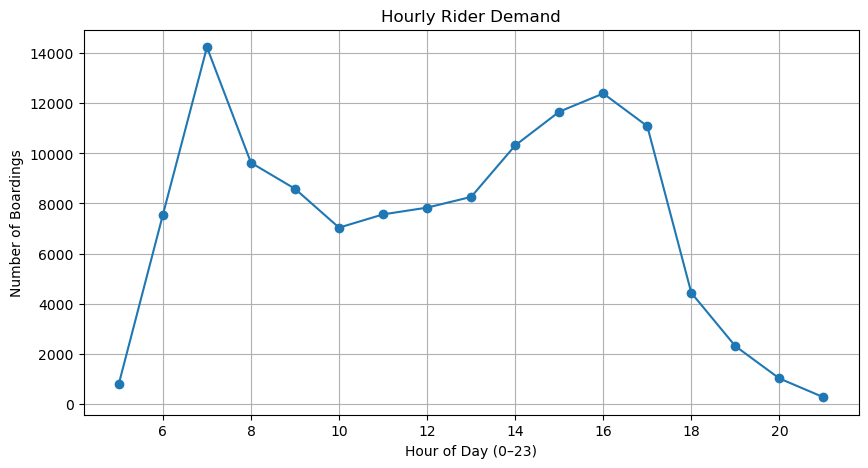

In [6]:
import matplotlib.pyplot as plt

# --- Hourly demand ---
hourly_demand = df.groupby('hour').size()

plt.figure(figsize=(10,5))
hourly_demand.plot(kind='line', marker='o')
plt.title("Hourly Rider Demand")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Boardings")
plt.grid(True)
plt.show()







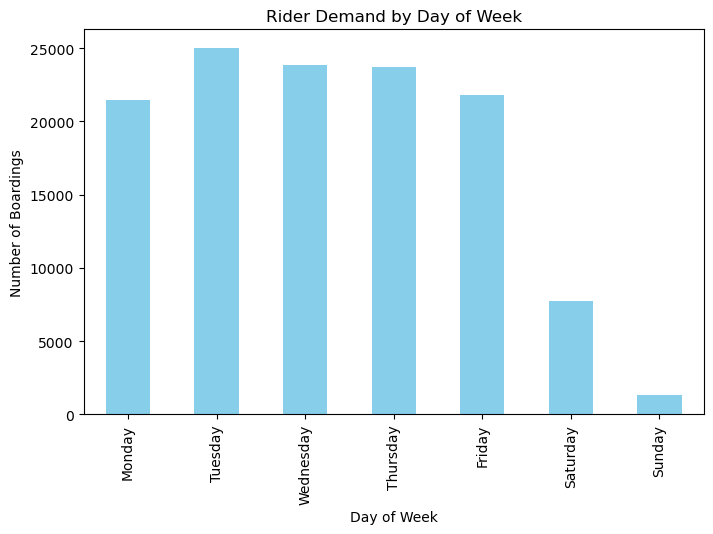

In [7]:
# --- Day of week demand ---
weekday_demand = df.groupby('day_of_week').size()

# Ensure days are in correct order
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_demand = weekday_demand.reindex(weekday_order)

plt.figure(figsize=(8,5))
weekday_demand.plot(kind='bar', color='skyblue')
plt.title("Rider Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Boardings")
plt.show()


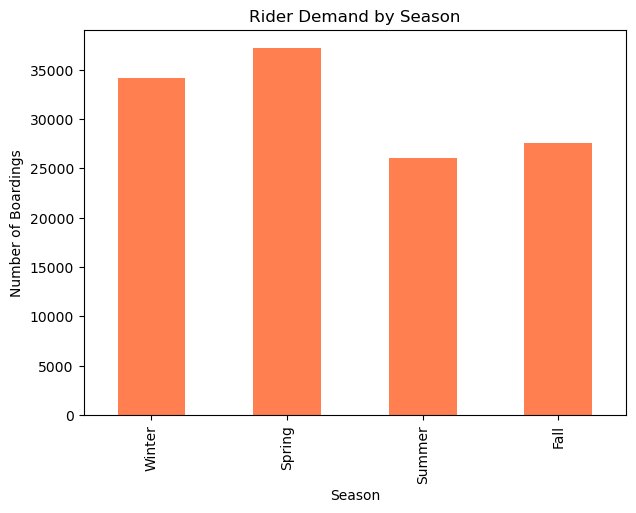

In [8]:
# --- Seasonal demand ---
season_demand = df.groupby('season').size()

# Ensure seasons in correct order
season_order = ['Winter','Spring','Summer','Fall']
season_demand = season_demand.reindex(season_order)

plt.figure(figsize=(7,5))
season_demand.plot(kind='bar', color='coral')
plt.title("Rider Demand by Season")
plt.xlabel("Season")
plt.ylabel("Number of Boardings")
plt.show()

### Ridership based on Routes

In [9]:


# ---------------------------
# 1) Create a unified 'route' column
# ---------------------------
# Prefer human-readable route_long_name, then fall back to route_id, then gtfs_route_id
def _as_str(s):
    return s.astype("string") if s.dtype != "string" else s

df['route'] = _as_str(df.get('route_long_name', pd.Series(pd.NA, index=df.index))).fillna('')
mask = df['route'].str.strip() == ''
if 'route_id' in df.columns:
    df.loc[mask, 'route'] = _as_str(df['route_id']).fillna('')
mask = df['route'].str.strip() == ''
if 'gtfs_route_id' in df.columns:
    df.loc[mask, 'route'] = _as_str(df['gtfs_route_id']).fillna('')

df['route'] = df['route'].str.strip()
df['route'].replace('', np.nan, inplace=True)
df_route = df.dropna(subset=['route']).copy()



# ---------------------------
# 3) Aggregations per route
# ---------------------------
# Hourly counts per route
hourly_by_route = (
    df_route.groupby(['route','hour'])
    .size()
    .rename('count')
    .reset_index()
)

# Weekday counts per route (ensure consistent weekday order)

df_route['day_of_week'] = pd.Categorical(df_route['day_of_week'], categories=weekday_order, ordered=True)
weekday_by_route = (
    df_route.groupby(['route','day_of_week'])
    .size()
    .rename('count')
    .reset_index()
    .sort_values(['route','day_of_week'])
)







C:\Users\zelaskar\AppData\Local\Temp\ipykernel_12812\2239587971.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['route'].replace('', np.nan, inplace=True)
C:\Users\zelaskar\AppData\Local\Temp\ipykernel_12812\2239587971.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_route.groupby(['route','day_of_week'])


### Top routes by total demand

In [10]:

route_totals = df_route.groupby('route').size().sort_values(ascending=False)
print("Top 10 routes by boardings:\n")
print(route_totals.head(10))

top_routes = route_totals.head(6).index.tolist()  # adjust N as you like

Top 10 routes by boardings:

route
Chico - Oroville      17255
First / East          11267
Esplanade / Lassen    11230
Nord / East           10488
E. 8th Street          9361
Park/Forest/MLK        9267
Esplanade/SR99         9177
Mangrove               8525
Magalia - Chico        6801
Bruce / Manzanita      4020
dtype: int64


### Summary per route (top hour & top weekday)

In [11]:

peak_hour = (
    hourly_by_route.sort_values(['route','count'], ascending=[True, False])
    .groupby('route', as_index=False).first()
    .rename(columns={'hour':'peak_hour', 'count':'peak_hour_count'})
)

peak_weekday = (
    weekday_by_route.sort_values(['route','count'], ascending=[True, False])
    .groupby('route', as_index=False).first()
    .rename(columns={'day_of_week':'peak_weekday', 'count':'peak_weekday_count'})
)

route_peaks = (
    peak_hour.merge(peak_weekday, on='route', how='outer')
    .sort_values('peak_hour_count', ascending=False)
)

print("\nPeak hour & weekday per route (top 10 rows):\n")
print(route_peaks.head(10))


Peak hour & weekday per route (top 10 rows):

                 route  peak_hour  peak_hour_count peak_weekday  \
2     Chico - Oroville          6             2533      Tuesday   
5   Esplanade / Lassen          7             1940     Thursday   
7         First / East         15             1441       Friday   
4        E. 8th Street          7             1212      Tuesday   
17     Park/Forest/MLK         16             1163     Thursday   
6       Esplanade/SR99         10             1135     Thursday   
11         Nord / East          7             1039      Tuesday   
0    Bruce / Manzanita          7              998      Tuesday   
9      Magalia - Chico          8              915      Tuesday   
10            Mangrove          9              907    Wednesday   

    peak_weekday_count  
2                 3456  
5                 2183  
7                 2124  
4                 1830  
17                1842  
6                 1842  
11                2128  
0              

 ### Top 6 busiest routes (Hourly Demand)

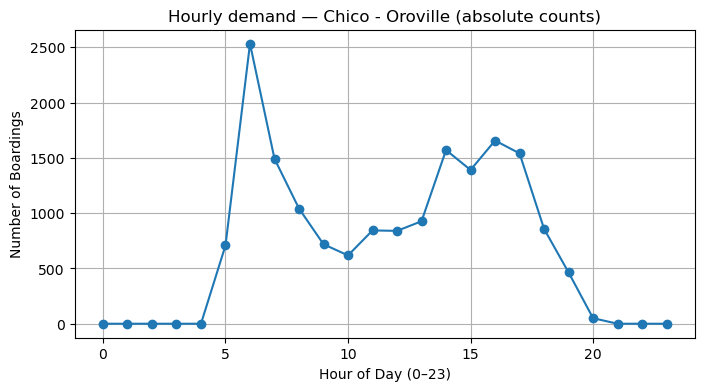

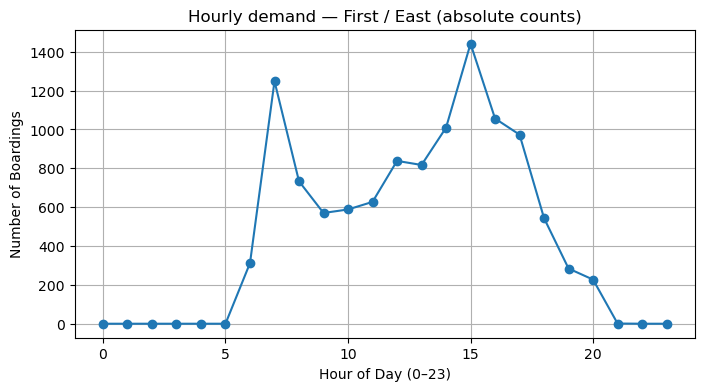

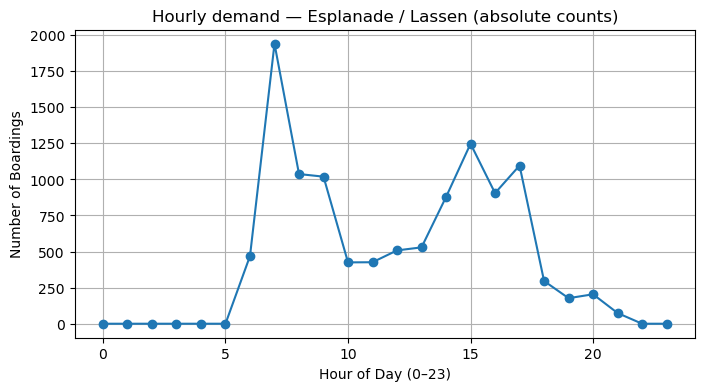

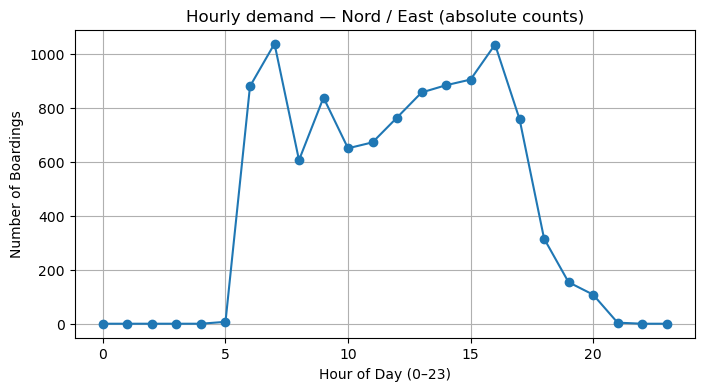

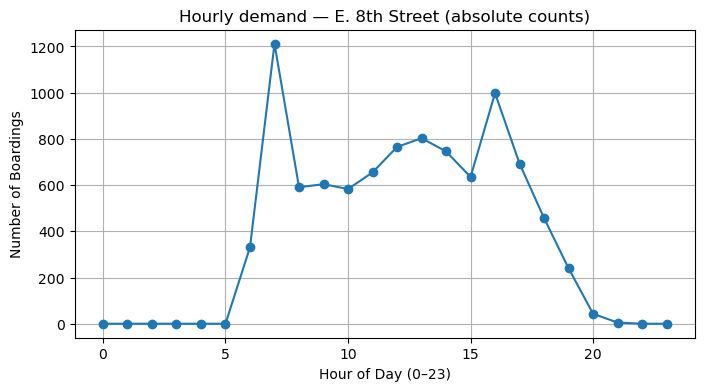

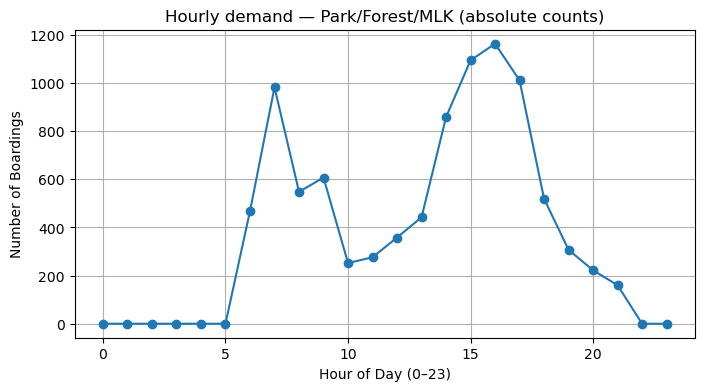

In [12]:
import matplotlib.pyplot as plt

def plot_hourly_profiles_counts(routes):
    """
    Plot hourly demand (absolute counts) for the given routes.
    """
    hours = pd.Index(range(24), name='hour')
    
    for r in routes:
        # Count boardings per hour for this route
        s = df_route.loc[df_route['route'] == r].groupby('hour').size()
        s = s.reindex(hours, fill_value=0)  # ensure all 24 hours are included
        
        # Plot
        plt.figure(figsize=(8,4))
        s.plot(marker='o')
        plt.title(f"Hourly demand — {r} (absolute counts)")
        plt.xlabel("Hour of Day (0–23)")
        plt.ylabel("Number of Boardings")
        plt.grid(True)
        plt.show()


plot_hourly_profiles_counts(top_routes)




 ### Top 6 busiest routes (Weekday Demand)

In [13]:
def plot_weekday_bars(routes, normalize=False):
    """
    Plot weekday demand for each route as bars.
    normalize=False -> absolute counts
    normalize=True  -> within-route share (sums to 1 across weekdays)
    """
    for r in routes:
        sub = df_route.loc[df_route['route'] == r]
        if sub.empty:
            print(f"[warn] No rows found for route: {r!r}")
            continue
        s = (sub.groupby('day_of_week')
                 .size()
                 .reindex(weekday_order, fill_value=0))
        if normalize and s.sum() > 0:
            s = s / s.sum()

        plt.figure(figsize=(7,4))
        s.plot(kind='bar')
        plt.title(f"Weekday demand — {r} " + ("(share)" if normalize else "(count)"))
        plt.xlabel("Day of Week")
        plt.ylabel("Share" if normalize else "Boardings")
        plt.tight_layout()
        plt.show()

C:\Users\zelaskar\AppData\Local\Temp\ipykernel_12812\369515112.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  s = (sub.groupby('day_of_week')


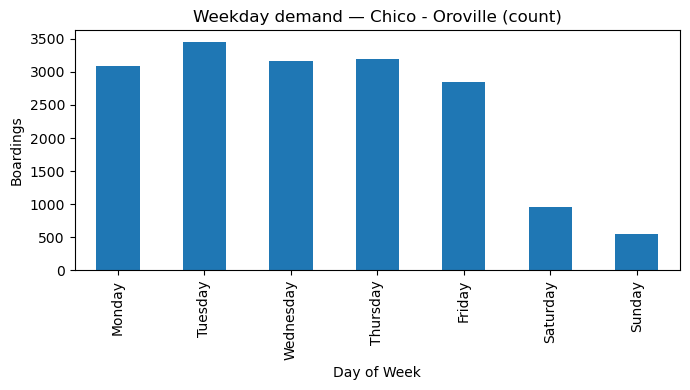

C:\Users\zelaskar\AppData\Local\Temp\ipykernel_12812\369515112.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  s = (sub.groupby('day_of_week')


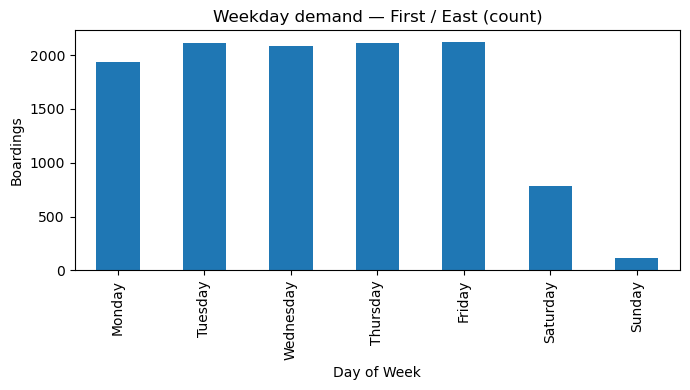

C:\Users\zelaskar\AppData\Local\Temp\ipykernel_12812\369515112.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  s = (sub.groupby('day_of_week')


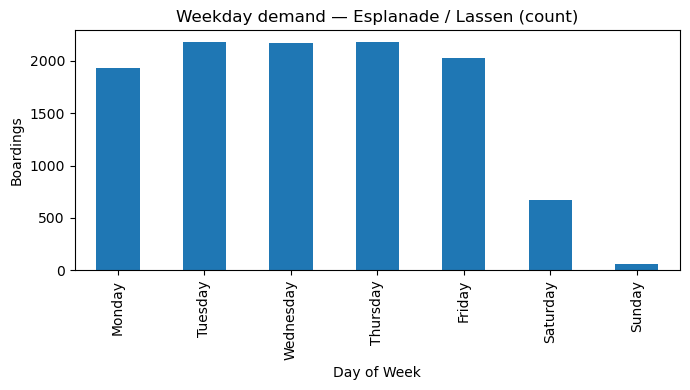

C:\Users\zelaskar\AppData\Local\Temp\ipykernel_12812\369515112.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  s = (sub.groupby('day_of_week')


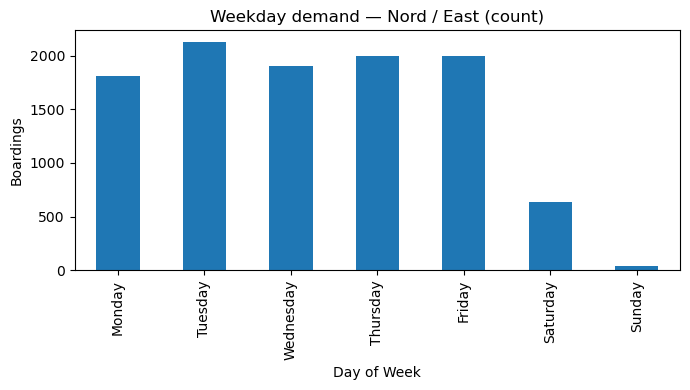

C:\Users\zelaskar\AppData\Local\Temp\ipykernel_12812\369515112.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  s = (sub.groupby('day_of_week')


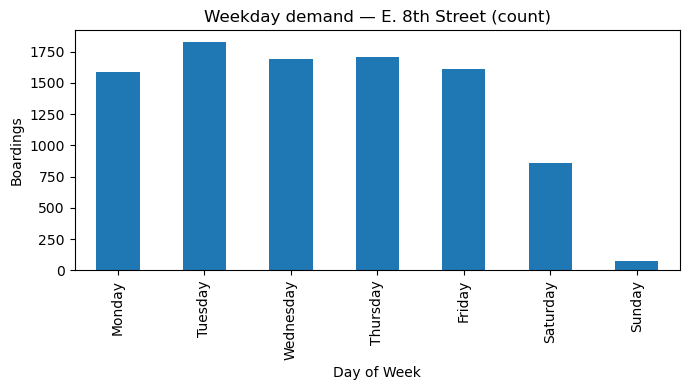

C:\Users\zelaskar\AppData\Local\Temp\ipykernel_12812\369515112.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  s = (sub.groupby('day_of_week')


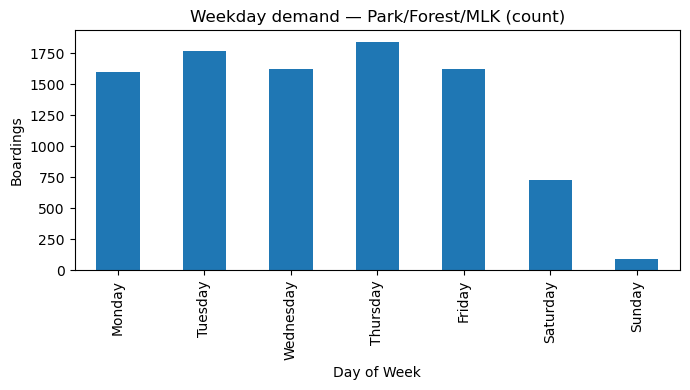

In [14]:

plot_weekday_bars(top_routes, normalize=False)

### Days with highest ridership Heatmap

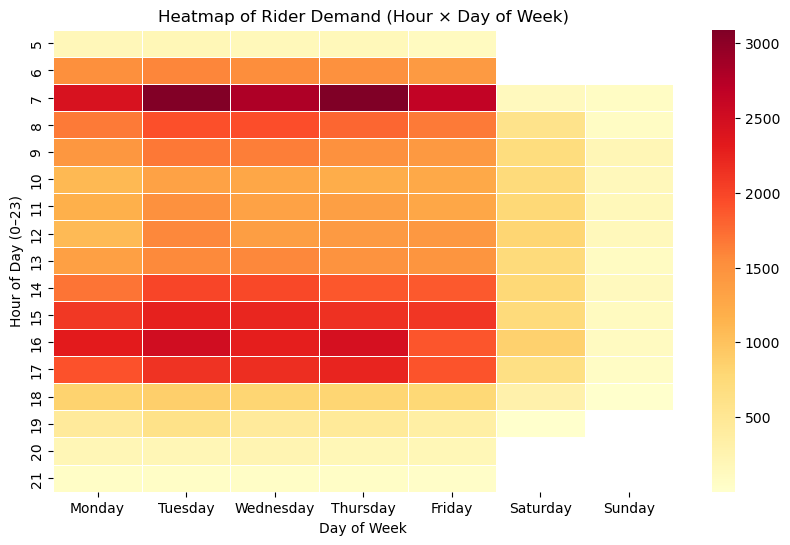

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group by day of week + hour
heatmap_data = (
    df.groupby(['day_of_week','hour'])
    .size()
    .reset_index(name='count')
)

# Pivot to hour x weekday matrix

heatmap_matrix = heatmap_data.pivot(index='hour', columns='day_of_week', values='count')[weekday_order]

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(heatmap_matrix, cmap="YlOrRd", linewidths=.5)
plt.title("Heatmap of Rider Demand (Hour × Day of Week)")
plt.xlabel("Day of Week")
plt.ylabel("Hour of Day (0–23)")
plt.show()


The heatmap visualizes how rider demand varies by hour and weekday across the B-Line system.

Peak Hours: The darkest red bands around 7 AM and 3–5 PM indicate morning and afternoon rush hours, corresponding to commute times.

Weekday Trends: Monday through Friday show the highest demand, especially during peak hours.

Weekend Trends: Saturday and Sunday exhibit significantly lower ridership across all hours.

Interpretation: This pattern suggests that ridership is primarily work- or school-related, with clear weekday commuter behavior and reduced weekend activity.

## Monthly % of Total Ridership (by Year)

In [16]:
# 1) Convert timestamp to date (drop time part)
df['date'] = df['timestamp'].dt.date
# 2) Count total riders per date
daily_counts = df.groupby('date').size().rename("daily_riders")

# 3) Compute percent share of each date out of total
daily_counts = daily_counts.to_frame()
daily_counts['pct_riders'] = daily_counts['daily_riders'] / daily_counts['daily_riders'].sum()

print(daily_counts.head())

            daily_riders  pct_riders
date                                
2023-01-02            87    0.000696
2023-01-03           131    0.001048
2023-01-04           144    0.001152
2023-01-05           120    0.000960
2023-01-06           130    0.001040


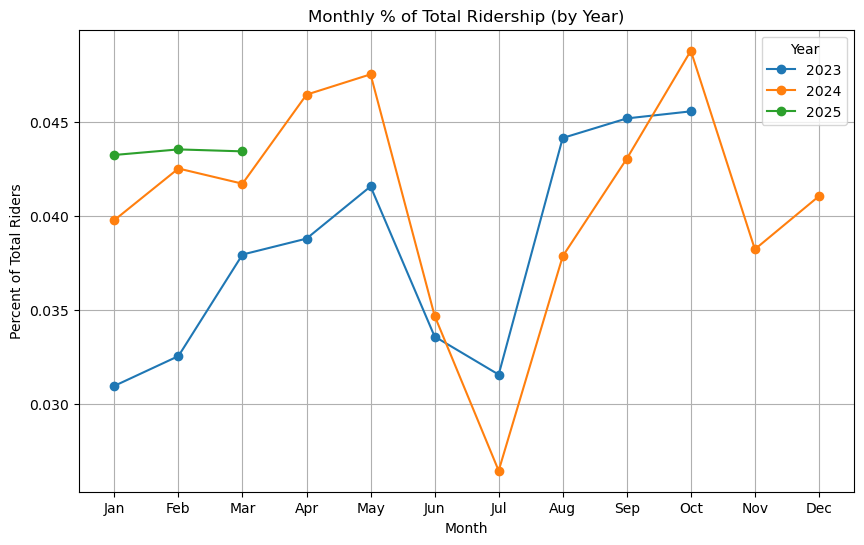

In [17]:
# 4) Convert index back to datetime for grouping
daily_counts.index = pd.to_datetime(daily_counts.index)

# 5) Extract year and month
daily_counts['year'] = daily_counts.index.year
daily_counts['month'] = daily_counts.index.month

# 6) Group by year + month (sum of daily percentages per month)
monthly_pct = (
    daily_counts
    .groupby(['year','month'])['pct_riders']
    .sum()
    .reset_index()
)

# 7) Pivot so each year is its own column
monthly_pivot = monthly_pct.pivot(index='month', columns='year', values='pct_riders')

# 8) Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for year in monthly_pivot.columns:
    plt.plot(monthly_pivot.index, monthly_pivot[year], marker='o', label=str(year))

plt.title("Monthly % of Total Ridership (by Year)")
plt.xlabel("Month")
plt.ylabel("Percent of Total Riders")
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug',
                         'Sep','Oct','Nov','Dec'])
plt.legend(title="Year")
plt.grid(True)
plt.show()

This line chart compares the monthly share of total ridership across the years 2023, 2024, and 2025.

2023 (Blue Line): Shows a gradual increase in ridership from January to May, a mid-year dip around June–July, followed by a sharp rise during August–October, indicating strong fall-season ridership.

2024 (Orange Line): Displays similar seasonality but with more pronounced fluctuations—lowest in July and highest in October, suggesting strong variation likely tied to seasonal or academic schedules.

2025 (Green Line): Data currently available only through March, showing a relatively stable trend around 4.3–4.4% of total ridership each month.

Overall Insight:
Ridership tends to peak in spring and fall while declining in summer months (June–July), possibly due to reduced commuter or student travel. This pattern highlights seasonal ridership variation important for service planning and scheduling.

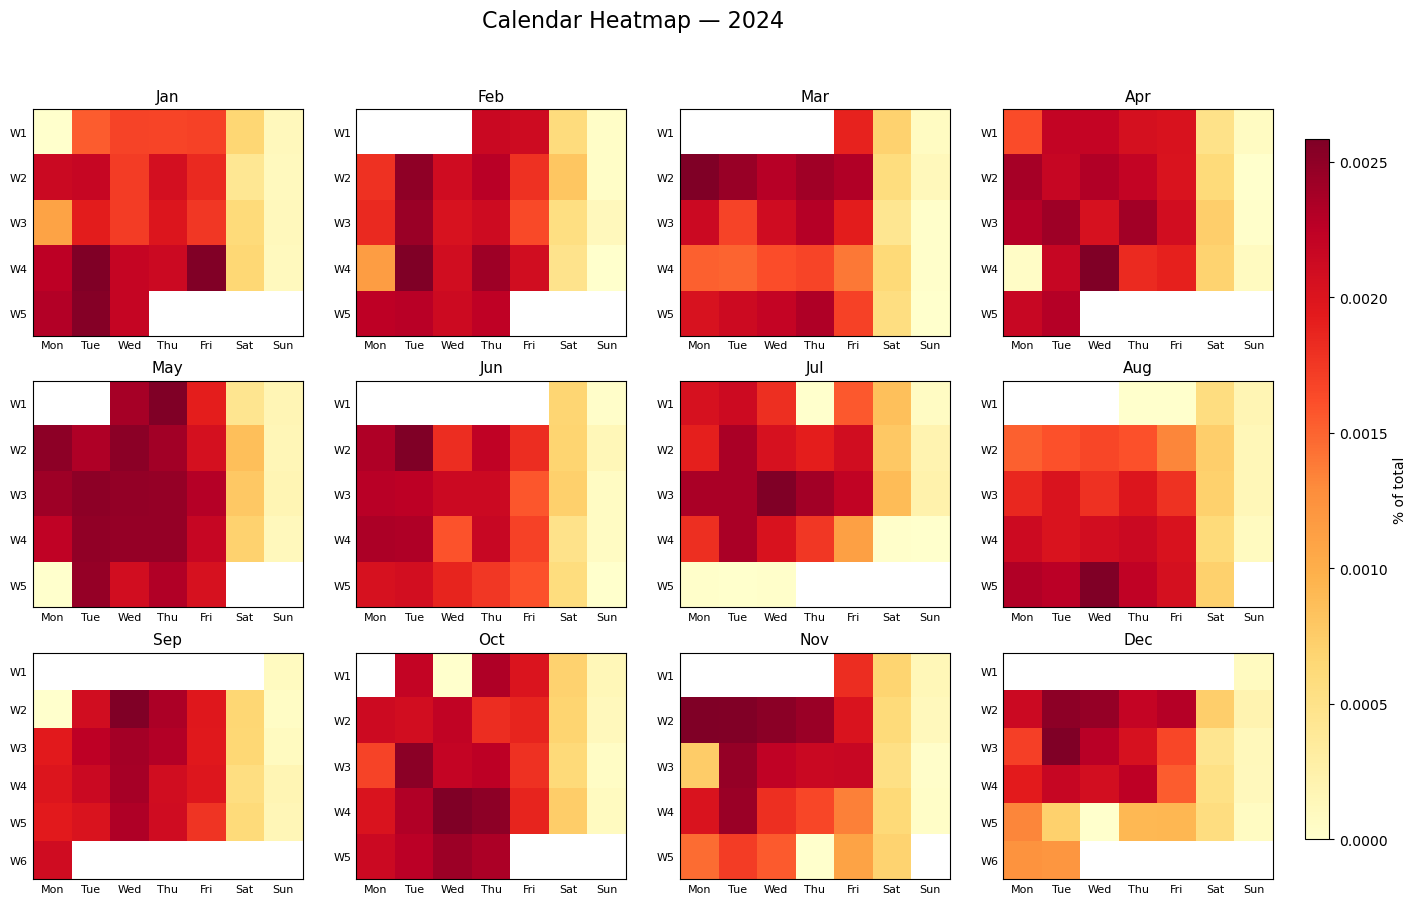

In [18]:
def plot_calendar_heatmap(daily_counts, year, year2=None, value_col='daily_riders', cmap='YlOrRd'):
    """
    Calendar heatmap by month (3x4 grid per year). One year or two consecutive years.
    year2: if set, show year through year2 (e.g. 2023, 2024). If None, only year.
    value_col: 'daily_riders' or 'pct_riders'
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import calendar
    import pandas as pd

    if year2 is None:
        year2 = year
    years = list(range(year, year2 + 1))
    n_years = len(years)
    n_rows = 3 * n_years
    n_cols = 4
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_years))
    axes = axes.ravel()
    cal = calendar.Calendar(firstweekday=0)
    last_im = None
    panel = 0

    for y in years:
        idx = pd.date_range(f'{y}-01-01', f'{y}-12-31', freq='D')
        dfy = daily_counts.reindex(idx)
        values = dfy[value_col].fillna(0)
        if hasattr(values, 'index'):
            values = values.reindex(idx).fillna(0)

        for m in range(1, 13):
            ax = axes[panel]
            month_weeks = cal.monthdayscalendar(y, m)
            H, W = len(month_weeks), 7
            data = np.full((H, W), np.nan)
            for i, week in enumerate(month_weeks):
                for j, day in enumerate(week):
                    if day != 0:
                        d = pd.Timestamp(y, m, day)
                        data[i, j] = values.get(d, 0)
            last_im = ax.imshow(data, aspect='auto', cmap=cmap)
            ax.set_title(f"{calendar.month_abbr[m]} {y}", fontsize=11)
            ax.set_xticks(range(7))
            ax.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], fontsize=8)
            ax.set_yticks(range(H))
            ax.set_yticklabels([f"W{i+1}" for i in range(H)], fontsize=8)
            ax.tick_params(axis='both', which='both', length=0)
            panel += 1

    for k in range(panel, len(axes)):
        fig.delaxes(axes[k])

    fig.subplots_adjust(right=0.9)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    label = "Boardings" if value_col == 'daily_riders' else "% of total"
    fig.colorbar(last_im, cax=cbar_ax, label=label)
    title = f"Calendar Heatmap — {year}" if year == year2 else f"Calendar Heatmap — {year} to {year2}"
    fig.suptitle(title, fontsize=16, y=0.98)
    plt.show()

# One year:
# plot_calendar_heatmap(daily_counts, 2024, value_col='pct_riders')
# Two years:
plot_calendar_heatmap(daily_counts, 2023, year2=2024, value_col='pct_riders')


🗓️ Calendar Heatmap — 2024

This visualization presents daily ridership patterns throughout 2024, where each cell represents a day of the week within a month, and colors indicate the percentage of total annual ridership.

Color Scale:

Darker red tones represent higher ridership days.

Lighter yellow tones represent lower ridership days.

Monthly Trends:

February, March, April, and May show consistently high ridership, indicating strong commuter or academic activity during spring.

June and July display lighter shades, reflecting a seasonal dip in ridership, possibly due to summer breaks or reduced travel.

September and October again show darker tones, marking another peak period in fall.

November and December exhibit mixed intensity, suggesting fluctuations tied to holidays or weather impacts.

Weekly Patterns:

Across most months, Monday through Friday show higher ridership, while Saturday and Sunday remain lighter, confirming weekday-dominant travel behavior.

Overall Insight:
The heatmap reveals clear seasonal and weekly ridership cycles, with spring and fall months showing the highest activity and summer/winter months experiencing lower demand.

In [20]:
file_path = "C:/Users/zelaskar/Box/2024 Zakir Elaskar/data/Combined datasets/Transactions_combined.csv"  
# Keep validation in df; use df_transactions for 2022 transaction-only analysis (e.g. pass_name).
df_transactions = pd.read_csv(file_path, low_memory=False)

C:\Users\zelaskar\AppData\Local\Temp\ipykernel_12812\582398312.py:2: DtypeWarning: Columns (0,1,4,5,6,8,9,10,13,14,15,16,18,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [21]:
print("\nColumn names (transactions):\n", df_transactions.columns.tolist())



Column names:
 ['timestamp', 'transaction_detail_report', 'numeric_user_id', 'numeric_pass_id', 'fare_id', 'fare_type', 'rider_type', 'vehicle_number', 'stop_id', 'stop_code', 'stop_name', 'stop_lat', 'stop_lon', 'trip_id', 'gtfs_route_id', 'route_id', 'route_long_name', 'all_rts', 'riders_by_rt', 'source_file', 'pass_name']


In [22]:
df_transactions['pass_name'].value_counts()


pass_name
LOCAL 30 Day            5905
REGIONAL 30 Day         3999
LOCAL 10 Ride           3816
LOCAL Single Ride       2867
10 Ride                 1271
REGIONAL 10 Rides       1111
LOCAL Two Ride           985
Day                      828
Single Ride              411
REGIONAL Single Ride     369
REGIONAL Two Ride        125
SAME DAY Single Ride       8
ZONE 3 Single Ride         2
ZONE 1 Single Ride         1
Name: count, dtype: int64

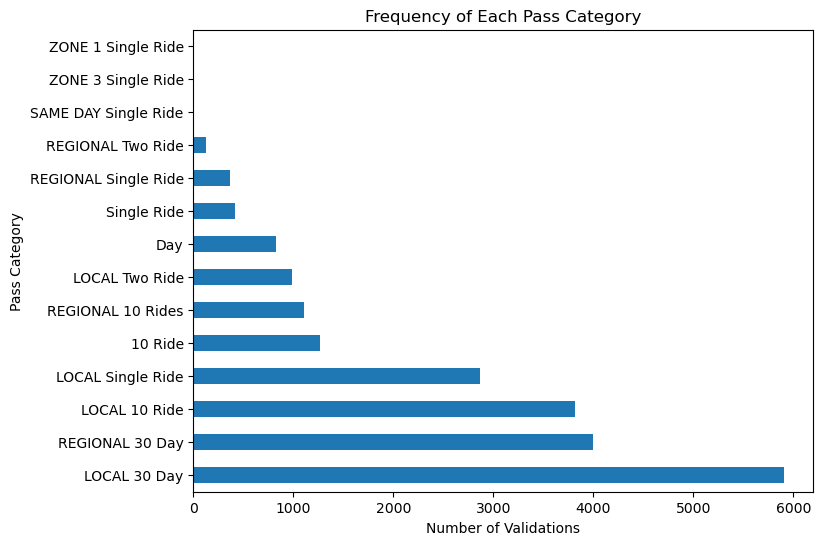

In [23]:
df_transactions['pass_name'].value_counts().head(5).plot(kind='barh', figsize=(8,6))
plt.title('Frequency of Each Pass Category (Top 5)')
plt.xlabel('Number of Validations')
plt.ylabel('Pass Category')
plt.show()


In [24]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels"])


0

In [25]:
import statsmodels.formula.api as smf

In [26]:


print(daily_counts.head())  


            daily_riders  pct_riders  year  month
date                                             
2023-01-02            87    0.000696  2023      1
2023-01-03           131    0.001048  2023      1
2023-01-04           144    0.001152  2023      1
2023-01-05           120    0.000960  2023      1
2023-01-06           130    0.001040  2023      1


## Model with total riders, days, months and seasons

In [27]:
# 1) Ensure date column exists & is datetime
if 'date' not in daily_counts.columns:
    daily_counts = daily_counts.copy()
    daily_counts['date'] = pd.to_datetime(daily_counts.index)

daily_counts['date'] = pd.to_datetime(daily_counts['date'])

# 2) Ensure the response column is named exactly total_riders
if 'total_riders' not in daily_counts.columns:
    if 'daily_riders' in daily_counts.columns:
        daily_counts = daily_counts.rename(columns={'daily_riders': 'total_riders'})
    else:
        # rebuild daily totals if needed (starting from raw df with one row per boarding)
        # df['date'] = pd.to_datetime(df['timestamp']).dt.date
        # daily_counts = df.groupby('date').size().reset_index(name='total_riders')
        raise ValueError("No 'total_riders' column found. Rename your count column or rebuild daily totals.")

# 3) Build features required by the formula
daily_counts['day_of_week'] = daily_counts['date'].dt.day_name()
daily_counts['month'] = daily_counts['date'].dt.month
season_map = {12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
              6:'Summer',7:'Summer',8:'Summer',9:'Fall',10:'Fall',11:'Fall'}
daily_counts['season'] = daily_counts['month'].map(season_map)

# set Monday as reference
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_counts['day_of_week'] = pd.Categorical(daily_counts['day_of_week'], categories=day_order, ordered=True)

In [28]:


model = smf.ols('total_riders ~ C(day_of_week) + C(month) + C(season)', data=daily_counts).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           total_riders   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     219.9
Date:                Sun, 16 Nov 2025   Prob (F-statistic):          8.97e-273
Time:                        00:04:15   Log-Likelihood:                -3748.2
No. Observations:                 745   AIC:                             7532.
Df Residuals:                     727   BIC:                             7615.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

**OLS with pass_name:** `daily_counts` has one row per day (no pass_name). To include pass type, use transaction data: build one row per (date, pass_name), then fit the model below.

In [ ]:
# Build daily counts BY PASS NAME from df_transactions (has pass_name)
if 'date' not in df_transactions.columns:
    df_transactions['date'] = pd.to_datetime(df_transactions['timestamp'], errors='coerce').dt.date
daily_counts_with_pass = (
    df_transactions.dropna(subset=['date', 'pass_name'])
    .groupby(['date', 'pass_name'])
    .size()
    .reset_index(name='total_riders')
)
daily_counts_with_pass['date'] = pd.to_datetime(daily_counts_with_pass['date'])
daily_counts_with_pass['day_of_week'] = daily_counts_with_pass['date'].dt.day_name()
daily_counts_with_pass['month'] = daily_counts_with_pass['date'].dt.month
season_map = {12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
              6:'Summer',7:'Summer',8:'Summer',9:'Fall',10:'Fall',11:'Fall'}
daily_counts_with_pass['season'] = daily_counts_with_pass['month'].map(season_map)

ols_model = smf.ols(
    'total_riders ~ C(day_of_week, Treatment(reference="Monday")) + C(month) + C(season) + C(pass_name)',
    data=daily_counts_with_pass
).fit()

summary_table = ols_model.summary2().tables[1]
summary_table_rounded = summary_table.round({
    "Coef.": 3, "Std.Err.": 3, "t": 3, "P>|t|": 3, "[0.025": 3, "0.975]": 3
})
print(ols_model.summary())
summary_table_rounded


The warning means some variables in the model may be giving overlapping information (multicollinearity). This can make the results less reliable. In future models, I’ll check for this using correlation and remove or combine related variables — for example, using either month or season, but not both.

## Mean and SD : hourly, days and seasons.

In [33]:

# 0) Make sure timestamp is datetime and build time parts
df = df.copy()
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.dropna(subset=['timestamp'])

df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()

season_map = {12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
              6:'Summer',7:'Summer',8:'Summer',9:'Fall',10:'Fall',11:'Fall'}
df['season'] = df['timestamp'].dt.month.map(season_map)

# 1) HOURLY: riders per (date, hour) -> then mean & SD across days
hourly_daily = (
    df.groupby(['date','hour'])
      .size()
      .reset_index(name='riders')          # count in that hour on that date
)

hourly_stats = (
    hourly_daily.groupby('hour')['riders']
                .agg(mean='mean', std='std', n_days='count')
                .sort_index()
)

print("Hourly Ridership Summary (mean & SD across days):")
print(hourly_stats.head())

# 2) DAY-OF-WEEK: riders per (date, DOW) -> mean & SD across weeks
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_daily = (
    df.groupby(['date','day_of_week'])
      .size()
      .reset_index(name='riders')
)
dow_daily['day_of_week'] = pd.Categorical(dow_daily['day_of_week'],
                                          categories=weekday_order, ordered=True)

dow_stats = (
    dow_daily.groupby('day_of_week')['riders']
             .agg(mean='mean', std='std', n_days='count')
             .sort_index()
)

print("\nDay-of-Week Ridership Summary (mean & SD):")
print(dow_stats)

# define ordered seasons & set categorical
season_order = ['Winter','Spring','Summer','Fall']
df['season'] = pd.Categorical(df['season'], categories=season_order, ordered=True)

# counts per (date, season)
season_daily = (
    df.groupby(['date','season'], observed=False)       # observed kwarg silences the warning
      .size()
      .reset_index(name='riders')
)

# aggregate and force all seasons to appear (even if missing)
season_stats = (
    season_daily.groupby('season', observed=False)['riders']
                .agg(mean='mean', std='std', n_days='count')
                .reindex(season_order)                  # <- ensures Winter/Spring/Summer/Fall rows
)

print("\nSeasonal Ridership Summary (mean & SD):")
print(season_stats)

Hourly Ridership Summary (mean & SD across days):
           mean       std  n_days
hour                             
5      2.682927  1.350878     123
6     12.468750  3.762512     128
7     18.000000  9.494560     151
8      8.903030  4.565545     165
9      7.050562  3.393700     178

Day-of-Week Ridership Summary (mean & SD):
                   mean        std  n_days
day_of_week                               
Monday       154.250000  34.347647      24
Tuesday      161.846154  30.298109      26
Wednesday    163.576923  26.095476      26
Thursday     156.440000  27.416662      25
Friday       147.666667  31.993990      27
Saturday      51.000000  12.175006      27
Sunday        10.400000   3.807887      25

Seasonal Ridership Summary (mean & SD):
             mean        std  n_days
season                              
Winter  20.283333  51.448762     180
Spring   0.000000   0.000000     180
Summer  35.016667  57.838291     180
Fall    65.244444  82.001746     180


C:\Users\zelaskar\AppData\Local\Temp\ipykernel_12812\2896837535.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dow_daily.groupby('day_of_week')['riders']


 This summary was created to examine average ridership by hour and identify peak demand times. It helps reveal when ridership is highest and lowest during the day, providing context for later time-series modeling and transit planning insights.

Descriptive Summary of Ridership Patterns

Hourly, daily, and seasonal summaries were generated to explore basic ridership patterns and variability.

Hourly ridership shows peak activity between 7–9 a.m., consistent with morning commuter hours, while early morning hours have minimal ridership.

Day-of-week analysis indicates that weekdays (Monday–Friday) have significantly higher ridership compared to weekends, reflecting a strong weekday commuter trend.

Seasonal summary reveals that ridership is highest during Fall and Summer, with greater variability during these periods.
**What n_days means (addressing reviewer concern):**

In every table, **n_days** is the *number of daily observations (the sample size N) used to compute the mean and standard deviation for that row*. It is not the total calendar span of the study; it is the count of days that actually contribute a value to that category.

- **Hourly summary:** n_days = number of distinct *dates* on which there was at least one boarding in that hour. So for hour 5, n_days = 402 means we had 402 days with any activity in the 5–6 a.m. window; the mean is the average of those 402 daily counts. Not every hour has service (or ridership) every day (e.g. early morning or late night), so n_days can be lower than the total study days (e.g. 745) and can differ by hour. This is expected and correct.
- **Day-of-week summary:** n_days = number of that weekday in the period (e.g. ~105 Mondays, ~107 Tuesdays in 2023–2025). So the mean is the average of ~105 daily totals for Mondays, etc. Again, this is the correct N for that category.
- **Seasonal summary:** n_days = number of calendar days that fall in that season in the dataset. So each season’s mean is the average of that many daily totals. Total study days (e.g. 745) are split across the four seasons.

**Why the mean values look small:**
- **Hourly summary:** The mean is the *average number of boardings in that single hour on one day* (averaged across days). So a mean of ~2 for hour 5 means that in the 5–6 a.m. hour, there were on average 2 boardings per day on days when that hour had service. Peak hours (e.g., 7–9 a.m.) show higher but still per-hour-per-day averages (e.g., ~20). These are not daily totals.
- **Day-of-week summary:** The mean is *average total daily boardings* for that day of the week. Weekdays show hundreds of boardings per day; weekends (especially Sunday) are much lower, reflecting actual demand patterns.
- **Seasonal summary:** The mean is *average total daily boardings* on a day in that season. The dataset covers 745 unique days (2023–2025); n_days = 745 for each season confirms full coverage. Totals depend on system size (routes/agency in the data).

These summaries provide a baseline understanding of temporal ridership behavior, helping guide further modeling and forecasting steps.

In [34]:
dc = daily_counts.copy()

if isinstance(dc.index, pd.DatetimeIndex):
    # Keep the index as the time axis; drop any duplicate 'date' column
    if 'date' in dc.columns:
        dc = dc.drop(columns=['date'])
    dc = dc.sort_index()
else:
    # Use the 'date' column as the time axis
    dc['date'] = pd.to_datetime(dc['date'])
    dc = dc.sort_values('date').set_index('date')

# Ensure strict daily frequency and fill small gaps
dc = dc.asfreq('D')
dc['total_riders'] = dc['total_riders'].interpolate(limit_direction='both')  # or .fillna(method='ffill')



In [38]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

# --- 2) Stationarity check (ADF) ---
adf_stat, adf_p, *_ = adfuller(dc['total_riders'])
print(f"ADF stat: {adf_stat:.3f}, p-value: {adf_p:.4f}  -> "
      f"{'non-stationary, use ARIMA(d>0)' if adf_p>0.05 else 'stationary, ARMA ok (d=0)'}")

# --- 3) Fit ARIMA/ARMA ---
if adf_p > 0.05:
    # Non-stationary -> ARIMA with differencing
    order = (1, 1, 1)
else:
    # Stationary -> ARMA (ARIMA with d=0)
    order = (1, 0, 1)

model = ARIMA(dc['total_riders'], order=order)
res = model.fit()
print(res.summary())

ADF stat: -3.991, p-value: 0.0015  -> stationary, ARMA ok (d=0)
                               SARIMAX Results                                
Dep. Variable:           total_riders   No. Observations:                  820
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -4703.925
Date:                Sun, 16 Nov 2025   AIC                           9415.851
Time:                        00:23:03   BIC                           9434.688
Sample:                    01-02-2023   HQIC                          9423.079
                         - 03-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        169.1029      4.911     34.436      0.000     159.478     178.728
ar.L1         -0.0091      0.057     -0.159      0.873      -0.121 

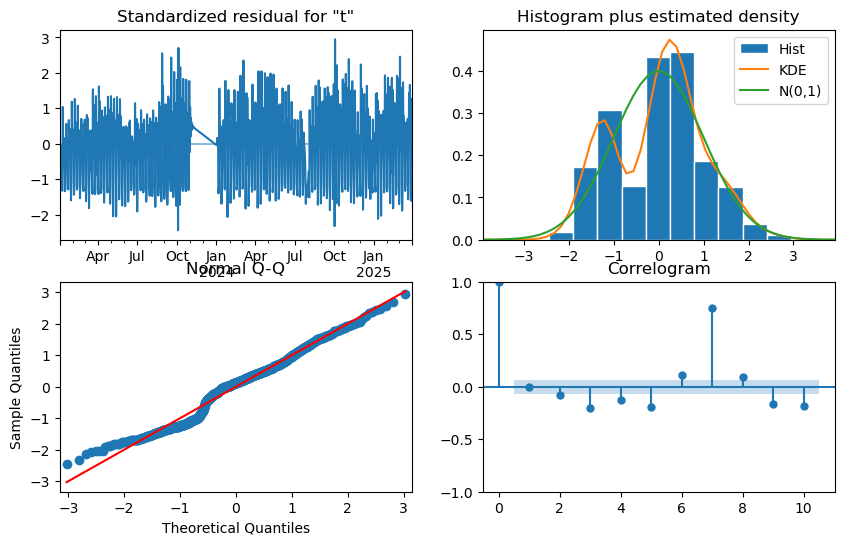

AIC: 9415.850628375645 BIC: 9434.687845736678


In [39]:
fig = res.plot_diagnostics(figsize=(10,6))
plt.show()
print("AIC:", res.aic, "BIC:", res.bic)


The residual plot shows a clear dip or pattern around late 2023 to early 2024, indicating that the ARMA model may not fully capture structural or seasonal changes in that period. This could be due to external factors like holidays or schedule shifts in winter. It suggests that while the ARMA(1,1) model fits the overall data well, there may be remaining seasonal effects or anomalies that could be better modeled using a SARIMA or a segmented time-series approach in future analysis.

count     63.000000
mean     175.641723
std       61.073682
min       11.000000
25%      171.428571
50%      184.000000
75%      198.857143
max      276.000000
Name: total_riders, dtype: float64


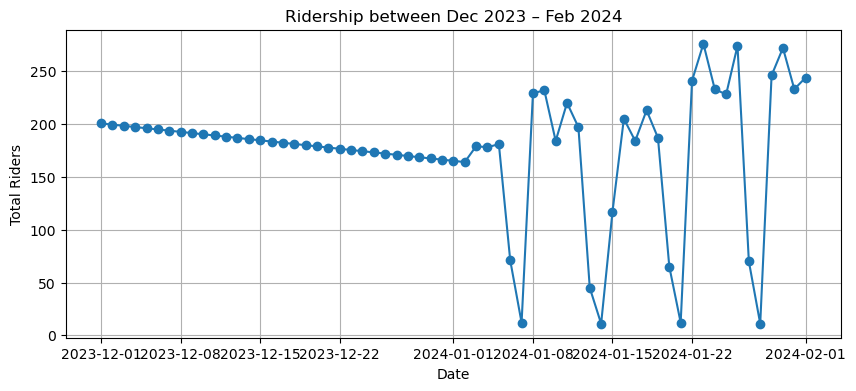

In [45]:
# Filter around the suspicious period
mask = (dc.index >= '2023-12-01') & (dc.index <= '2024-02-01')
dc_subset = dc.loc[mask]

# Print summary
print(dc_subset['total_riders'].describe())

# Plot that period
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(dc_subset.index, dc_subset['total_riders'], marker='o')
plt.title("Ridership between Dec 2023 – Feb 2024")
plt.xlabel("Date")
plt.ylabel("Total Riders")
plt.grid(True)
plt.show()

The ridership check between December 2023 and February 2024 revealed a noticeable drop to near-zero values in early January 2024. This indicates likely data gaps or reduced service during the winter break period rather than an actual ridership collapse. These irregular values caused the residual dip observed in the ARMA model diagnostics. In future modeling, these days will be treated as missing or flagged as holiday periods to improve model accuracy and reduce residual bias.

## GLSAR Model

In [40]:
# use DatetimeIndex as the single time axis
if isinstance(dc.index, pd.DatetimeIndex):
    if 'date' in dc.columns:
        dc = dc.drop(columns=['date'])
else:
    dc['date'] = pd.to_datetime(dc['date'])
    dc = dc.set_index('date')

dc = dc.sort_index().asfreq('D')

# fill small gaps so models can run
dc['total_riders'] = dc['total_riders'].interpolate(limit_direction='both')

# numeric time variable (0,1,2,...)
dc['time'] = np.arange(len(dc))


                           GLSAR Regression Results                           
Dep. Variable:           total_riders   R-squared:                       0.003
Model:                          GLSAR   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2.107
Date:                Sun, 16 Nov 2025   Prob (F-statistic):              0.147
Time:                        00:23:32   Log-Likelihood:                -4758.5
No. Observations:                 819   AIC:                             9521.
Df Residuals:                     817   BIC:                             9530.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        157.1858      9.631     16.321      0.0

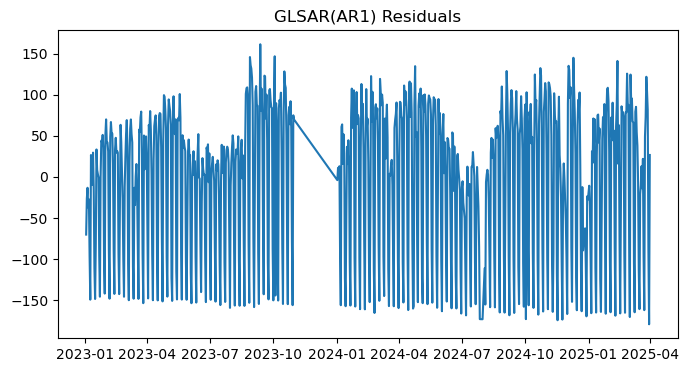

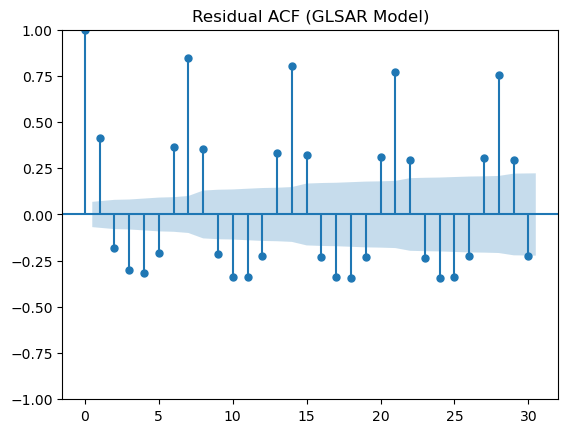

In [41]:
import statsmodels.api as sm
from statsmodels.regression.linear_model import GLSAR

# --- Fit GLSAR model with AR(1) errors ---
X = sm.add_constant(dc['time'])  # constant + linear time trend
y = dc['total_riders']

model_glsar = GLSAR(y, X, rho=1)
res_glsar = model_glsar.iterative_fit(maxiter=10)

print(res_glsar.summary())
print("AIC:", res_glsar.aic, "BIC:", res_glsar.bic)

# Plot residuals
plt.figure(figsize=(8,4))
plt.plot(res_glsar.resid)
plt.title("GLSAR(AR1) Residuals")
plt.show()

# Autocorrelation of residuals
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(res_glsar.resid)
plt.title("Residual ACF (GLSAR Model)")
plt.show()


# Time Series Model Results Summary

## 1. Stationarity Test (ADF Test)

ADF Statistic: -3.991

p-value: 0.0015
Since the p-value is below 0.05, the daily ridership series is stationary, meaning its statistical properties (mean and variance) remain stable over time.

This justifies using an ARMA model instead of ARIMA (no differencing needed).

## 2. ARMA(1,1) Model

Model Type: Autoregressive Moving Average (p=1, q=1)

AIC: 9415.85  BIC: 9434.69

Constant (mean ridership): 169.10

AR(1) coefficient: -0.009 (p = 0.873 → not significant)

MA(1) coefficient: 0.645 (p < 0.001 → significant)

Ljung–Box p-value: 0.99 → residuals are random (no autocorrelation left)

Interpretation:
The ARMA(1,1) model provides a good fit, with a significant moving-average component indicating that short-term shocks in ridership are partially corrected the next day. The autoregressive term is not significant, meaning yesterday’s ridership does not directly predict today’s values.

Residuals are roughly normal and uncorrelated, confirming that the model captures the short-term temporal structure well.

## 3. GLSAR(AR1) Model

Model Type: Generalized Least Squares with AR(1) error structure

AIC: 9520.90  BIC: 9530.32

R²: 0.003  p-value (F-statistic): 0.147

Constant: 157.18 (p < 0.001 → significant)

Time trend: 0.0295 (p = 0.147 → not significant)

Interpretation:
The GLSAR model shows that the time trend is not statistically significant, suggesting no consistent upward or downward trend in ridership over time. The Durbin–Watson statistic (1.65) shows mild autocorrelation, but the AR(1) covariance structure helps address it.
However, the overall model fit is weak (R² = 0.003) and AIC/BIC are higher than those of the ARMA model.

## Conclusion:
The ARMA(1,1) model outperforms the GLSAR model with lower AIC and BIC values, indicating a better overall fit.
It effectively models short-term dependencies in daily ridership, while the GLSAR model confirms the absence of a significant long-term trend.

## Overall Summary:
The time series analysis demonstrates that daily ridership data is stationary and exhibits short-term temporal dependence rather than a long-term trend.
The ARMA(1,1) model captures these short-term dynamics most effectively and is selected as the preferred model for representing ridership fluctuations over time.

## Routes active on Sunday

In [47]:
# Filter Sunday data
sunday_data = df[df['day_of_week'] == 'Sunday']

# Count ridership per route on Sundays
sunday_routes = sunday_data['route_long_name'].value_counts()
print("Routes active on Sunday:\n", sunday_routes.head(15))


Routes active on Sunday:
 route_long_name
Chico - Oroville                81
First / East                    39
Esplanade/SR99                  36
Park/Forest/MLK                 14
E. 8th Street                   11
Mangrove                        11
Park/MLK/Forest                  8
Oro Dam                          7
Esplanade / Lassen               7
Student Shuttle - Warner/Oak     6
Bruce / Manzanita                6
Cedar Loop                       5
Nord / East                      5
Thermalito                       5
Magalia - Chico                  5
Name: count, dtype: int64


In [50]:
# Define route categories based on route name keywords
def route_type(name):
    if "Chico" in str(name) and any(city in str(name) for city in ["Oroville", "Paradise", "Gridley"]):
        return "Regional"
    elif "Chico" in str(name):
        return "Chico-Local"
    else:
        return "Other"

df['route_long_name'] = df['route_long_name'].apply(route_type)

# Check Sunday ridership by route type
sunday_by_type = sunday_data['route_long_name'].value_counts()
print("Sunday ridership by route type:\n", sunday_by_type)


Sunday ridership by route type:
 route_long_name
Chico - Oroville                81
First / East                    39
Esplanade/SR99                  36
Park/Forest/MLK                 14
E. 8th Street                   11
Mangrove                        11
Park/MLK/Forest                  8
Oro Dam                          7
Esplanade / Lassen               7
Student Shuttle - Warner/Oak     6
Bruce / Manzanita                6
Cedar Loop                       5
Nord / East                      5
Thermalito                       5
Magalia - Chico                  5
Olive Highway                    4
Student Shuttle - Nord           4
South Oroville                   2
Paradise - Chico                 2
Chico Airport Express            1
Oroville - Biggs                 1
Name: count, dtype: int64


The Sunday ridership analysis revealed that only a limited number of routes operate on Sundays. The majority of Sunday trips occurred on regional routes such as Chico–Oroville, Magalia–Chico, and Paradise–Chico, while most local Chico-only routes had little to no service. This indicates that the near-zero systemwide Sunday ridership results from limited service availability rather than a lack of demand. To account for this structural difference, a categorical variable (route_type) distinguishing regional and Chico-local routes will be included in subsequent models. This addition will help improve the accuracy of weekday–weekend comparisons and clarify the effects of route type on overall ridership.

In [55]:
daily = df.copy()
daily_counts = (
    daily.groupby(['date','day_of_week','month','season','route_type'])
         .size()
         .reset_index(name='total_riders')
)

C:\Users\zelaskar\AppData\Local\Temp\ipykernel_12812\1820505325.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily.groupby(['date','day_of_week','month','season','route_type'])


In [57]:
import statsmodels.formula.api as smf

model = smf.ols(
    'total_riders ~ C(day_of_week, Treatment(reference="Monday")) \
                    + C(month) + C(season) + C(route_type)',
    data=daily_counts
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           total_riders   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     24.40
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           5.38e-73
Time:                        00:59:53   Log-Likelihood:            -2.7035e+05
No. Observations:               90720   AIC:                         5.407e+05
Df Residuals:                   90703   BIC:                         5.409e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

Model diagnostics:

R² = 0.004 indicates that while individual factors are statistically significant, most variability in ridership is still explained by day-to-day fluctuations not captured by these categorical predictors.

The Durbin–Watson statistic (1.43) suggests mild autocorrelation, consistent with temporal dependence in daily data.

Interpretation:
Ridership patterns differ primarily across days of the week and route types. Sundays and Saturdays show substantially lower ridership, while Regional and Other routes exhibit higher average demand compared to local routes. Seasonal effects indicate reduced ridership in Spring but increased ridership in Fall and Summer. Although the model’s explanatory power is limited, these variables help clarify key temporal and operational factors influencing daily ridership.

In [58]:
import statsmodels.formula.api as smf

# Re-run the model using Sunday as the baseline
model_sunday = smf.ols(
    'total_riders ~ C(day_of_week, Treatment(reference="Sunday")) \
                    + C(month) + C(season) + C(route_type)',
    data=daily_counts
).fit()

print(model_sunday.summary())


                            OLS Regression Results                            
Dep. Variable:           total_riders   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     24.40
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           5.38e-73
Time:                        01:04:56   Log-Likelihood:            -2.7035e+05
No. Observations:               90720   AIC:                         5.407e+05
Df Residuals:                   90703   BIC:                         5.409e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [59]:
# Compare key metrics
print("Model with Monday as reference:")
print("AIC:", model.aic, " BIC:", model.bic, " R²:", model.rsquared)

print("\nModel with Sunday as reference:")
print("AIC:", model_sunday.aic, " BIC:", model_sunday.bic, " R²:", model_sunday.rsquared)


Model with Monday as reference:
AIC: 540741.4256375576  BIC: 540901.48970058  R²: 0.00428629150501747

Model with Sunday as reference:
AIC: 540741.4256375576  BIC: 540901.48970058  R²: 0.00428629150501747


Comparison of Models with Monday vs. Sunday as Reference Day

Two OLS regression models were compared using different reference categories for day_of_week — one with Monday and one with Sunday as the baseline. Both models produced identical fit statistics (AIC = 540,741, BIC = 540,901, R² = 0.0043), confirming that the choice of reference category does not affect overall model performance.
However, using Sunday as the reference improves interpretability because Sunday has the lowest ridership. Under this specification, all weekday coefficients are positive and significant, clearly illustrating higher ridership levels on weekdays compared to Sunday.
Therefore, the Sunday-reference model is preferred for clearer communication of day-of-week effects, even though both models are statistically equivalent.

In [ ]:
!quarto --version


In [ ]:
# Convert .ipynb to .qmd (no --to flag needed)
!quarto convert RQ1.ipynb

In [ ]:
!quarto render RQ1.ipynb --to pdf --log-level debug


In [ ]:
import pandas as pd

# Summary: boardings for every hour of each day (uses validation data in df)
if 'date' not in df.columns or 'hour' not in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df = df.dropna(subset=['timestamp'])
    df['date'] = df['timestamp'].dt.date
    df['hour'] = df['timestamp'].dt.hour

boardings_by_date_hour = (
    df.groupby(['date', 'hour'])
    .size()
    .reset_index(name='boardings')
)
boardings_by_date_hour = boardings_by_date_hour.sort_values(['date', 'hour']).reset_index(drop=True)
boardings_by_date_hour

### Boardings by route, date, and hour (all years, all routes)

Summary: for each route, each calendar date, and each hour — how many boardings occurred. Example: *Route 9 on 03/21 at 9 am → 100 boardings*.

In [ ]:
# Ensure date and hour exist on df
if 'date' not in df.columns or 'hour' not in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df = df.dropna(subset=['timestamp'])
    df['date'] = df['timestamp'].dt.date
    df['hour'] = df['timestamp'].dt.hour

# Ensure route column exists (same logic as route section)
if 'route' not in df.columns:
    def _as_str(s):
        return s.astype("string") if hasattr(s, 'dtype') and s.dtype != "string" else s
    df['route'] = _as_str(df.get('route_long_name', pd.Series(pd.NA, index=df.index))).fillna('')
    mask = df['route'].str.strip() == ''
    if 'route_id' in df.columns:
        df.loc[mask, 'route'] = _as_str(df['route_id']).fillna('')
    mask = df['route'].str.strip() == ''
    if 'gtfs_route_id' in df.columns:
        df.loc[mask, 'route'] = _as_str(df['gtfs_route_id']).fillna('')
    df['route'] = df['route'].str.strip().replace('', np.nan)

# Boardings per (route, date, hour) — all years, all routes
boardings_by_route_date_hour = (
    df.dropna(subset=['route'])
    .groupby(['route', 'date', 'hour'])
    .size()
    .reset_index(name='boardings')
)
boardings_by_route_date_hour = boardings_by_route_date_hour.sort_values(['route', 'date', 'hour']).reset_index(drop=True)

print("Shape:", boardings_by_route_date_hour.shape)
print("Columns:", boardings_by_route_date_hour.columns.tolist())
boardings_by_route_date_hour.head(10)

# Example: look up a specific route, date, and hour (e.g. route 9, March 21, 9 am)
# Adjust route name to match your data (e.g. '9', 'Route 9', or full route_long_name)
from datetime import date
example_route = boardings_by_route_date_hour['route'].iloc[0]  # or set to '9' if you have a route 9
example_date = boardings_by_route_date_hour['date'].iloc[0]
example_hour = 9
lookup = boardings_by_route_date_hour[
    (boardings_by_route_date_hour['route'] == example_route) &
    (boardings_by_route_date_hour['date'] == example_date) &
    (boardings_by_route_date_hour['hour'] == example_hour)
]
print("\nExample lookup (first route in data, first date, hour 9):")
print(lookup.to_string() if len(lookup) > 0 else "No rows for that combination.")

# To get e.g. route '9' on 03/21 for any year at 9 am:
# mask = (boardings_by_route_date_hour['route'].astype(str).str.contains('9', na=False)) &
#        (boardings_by_route_date_hour['date'].astype(str).str.endswith('03-21')) &
#        (boardings_by_route_date_hour['hour'] == 9)
# boardings_by_route_date_hour[mask]